In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

project_root = os.path.dirname(os.path.abspath(''))
if project_root not in sys.path:
    sys.path.append(project_root)

# from MODELS.xgboostModel import *
from MODELS.ngboostModel import *
from PRODUCTION.pipeline import *
from FEATURES.features import *

In [69]:
pd.set_option('display.max_columns', None)

# s19 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_19.csv')
s20 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_20.csv')
s21 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_21.csv')
s22 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_22.csv')
s23 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_23.csv')
s24 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_24.csv')
s25 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_25.csv')
s26 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_26.csv')

for df in [s20,s21,s22,s23,s24,s25,s26]:
    df['GUARD_DEF_RATING_OVER_LEAGUE_AVG'] = df['GUARD'] * round(df['OPP_GUARD_DEF_RATING'] / df['LEAGUE_AVG_GUARD_DEF_RATING'], 2)
    df['FORWARD_DEF_RATING_OVER_LEAGUE_AVG'] = df['FORWARD'] * round(df['OPP_FORWARD_DEF_RATING'] / df['LEAGUE_AVG_FORWARD_DEF_RATING'], 2)
    df['CENTER_DEF_RATING_OVER_LEAGUE_AVG'] = df['CENTER'] * round(df['OPP_CENTER_DEF_RATING'] / df['LEAGUE_AVG_CENTER_DEF_RATING'], 2)
    df['POSS_VARIANCE_STABILITY'] = round(df['POSS_VOLATILITY_10_TO_DATE'] / (df['POSS_VOLATILITY_40_TO_DATE'] + 0.001), 2)


train_df = pd.concat([s20,s21,s22,s23,s24,s25])
val_df = s26

print("BEFORE FILTERING:")
print(f"Train set: {len(train_df)} samples")
print(f"Val set: {len(val_df)} samples")

BEFORE FILTERING:
Train set: 150115 samples
Val set: 6403 samples


In [70]:
player_season_avg = train_df.groupby('PLAYER_ID').agg({
    'MIN': 'mean',
    'PTS': 'mean',
    'GAMES_PLAYED_TO_DATE': 'max'
}).reset_index()

player_season_avg.columns = ['PLAYER_ID', 'MIN_AVG', 'PTS_AVG', 'GAMES_PLAYED']

# Define criteria for "relevant players"
relevant_players = player_season_avg[
    (player_season_avg['MIN_AVG'] >= 12) &      
    (player_season_avg['GAMES_PLAYED'] >= 8)
]['PLAYER_ID']

# Filter training data to only relevant players
train_df = train_df[train_df['PLAYER_ID'].isin(relevant_players)]
train_df = train_df[
    (train_df['PTS'] <= 50) &  
    (train_df['MIN'] <= 48)     
]
train_df = train_df.dropna(subset=['PTS_ROLLING_AVG_3'])

val_df = val_df[val_df['PLAYER_ID'].isin(relevant_players)]
val_df = val_df[
    (val_df['PTS'] <= 50) &  
    (val_df['MIN'] <= 48)     
]
val_df = val_df.dropna(subset=['PTS_ROLLING_AVG_3'])

print(f"Train set: {len(train_df)} samples")
print(f"Val set: {len(val_df)} samples")

Train set: 134310 samples
Val set: 4784 samples


In [57]:
featuresV4 = [
    # ===== CORE CONTEXT  =====
    'STARTING',
    'PLAYER_DAYS_REST',
    'PLAYER_IS_TEAM_STAR',
    'USUAL_STARTERS_AVAILABLE',
    'GAMES_PLAYED_TO_DATE',

    # ===== PLAYER BASELINES =====
    'MIN_AVG_TO_DATE',
    'PTS_AVG_TO_DATE',
    'FGA_AVG_TO_DATE',
    'FG3A_AVG_TO_DATE',
    'FTA_AVG_TO_DATE',
    'FG_PCT_AVG_TO_DATE',
    'FG3_PCT_AVG_TO_DATE',
    'FT_PCT_AVG_TO_DATE',
    'USG_PCT_AVG_TO_DATE',
    'TS_PCT_AVG_TO_DATE',
    'POSS_AVG_TO_DATE',
    'PLUS_MINUS_AVG_TO_DATE',

    # ===== ROLLING AVERAGES =====
    'PTS_L5_OVER_BASELINE',
    'PTS_L7_OVER_BASELINE',
    'PTS_L10_OVER_BASELINE',
    'MIN_L5_OVER_BASELINE',
    'MIN_L7_OVER_BASELINE',
    'MIN_L10_OVER_BASELINE',
    'FGA_L5_OVER_BASELINE',
    'FGA_L7_OVER_BASELINE',
    'FGA_L10_OVER_BASELINE',
    'FTA_L5_OVER_BASELINE',
    'FTA_L7_OVER_BASELINE',
    'FTA_L10_OVER_BASELINE',
    'FG3A_L5_OVER_BASELINE',
    'FG3A_L7_OVER_BASELINE',
    'FG3A_L10_OVER_BASELINE',
    'FG_PCT_L5_OVER_BASELINE',
    'FG_PCT_L7_OVER_BASELINE',
    'FG_PCT_L10_OVER_BASELINE',
    'FG3_PCT_L5_OVER_BASELINE',
    'FG3_PCT_L7_OVER_BASELINE',
    'FG3_PCT_L10_OVER_BASELINE',
    'FT_PCT_L5_OVER_BASELINE',
    'FT_PCT_L7_OVER_BASELINE',
    'FT_PCT_L10_OVER_BASELINE',
    'USG_PCT_L5_OVER_BASELINE',
    'USG_PCT_L7_OVER_BASELINE',
    'USG_PCT_L10_OVER_BASELINE',
    'TS_PCT_L5_OVER_BASELINE',
    'TS_PCT_L7_OVER_BASELINE',
    'TS_PCT_L10_OVER_BASELINE',
    'POSS_L5_OVER_BASELINE',
    'POSS_L7_OVER_BASELINE',
    'POSS_L10_OVER_BASELINE',
    'PLUS_MINUS_L5_OVER_BASELINE',
    'PLUS_MINUS_L7_OVER_BASELINE',
    'PLUS_MINUS_L10_OVER_BASELINE',
    
    # ===== Variance Stability =====
    'PTS_VARIANCE_STABILITY',
    'FGA_VARIANCE_STABILITY',
    'FG3A_VARIANCE_STABILITY',
    'FTA_VARIANCE_STABILITY',
    'FT_PCT_VARIANCE_STABILITY',
    'FG_PCT_VARIANCE_STABILITY',
    'FG3_PCT_VARIANCE_STABILITY',
    'USG_PCT_VARIANCE_STABILITY',
    'TS_PCT_VARIANCE_STABILITY',
    'POSS_VARIANCE_STABILITY', 
    
    # ===== STAR OUT DELTAS =====
    'PTS_BOOST_STAR_OUT',
    'FGA_BOOST_STAR_OUT',
    'FTA_BOOST_STAR_OUT',
    'USG_PCT_BOOST_STAR_OUT',
    'TS_PCT_BOOST_STAR_OUT',
    'FGM_BOOST_STAR_OUT',
    'FTM_BOOST_STAR_OUT',
    'FG3M_BOOST_STAR_OUT',
    'GAMES_WITHOUT_STAR',

    # === Standard Deviation ===
    'MIN_STD_5_TO_DATE',
    'MIN_STD_10_TO_DATE',
    'PTS_STD_5_TO_DATE',
    'PTS_STD_10_TO_DATE',
    'FGA_STD_5_TO_DATE',
    'FGA_STD_10_TO_DATE',
    'FG3A_STD_5_TO_DATE',
    'FG3A_STD_10_TO_DATE',
    'FTA_STD_5_TO_DATE',
    'FTA_STD_10_TO_DATE',
    'USG_PCT_STD_5_TO_DATE',
    'USG_PCT_STD_10_TO_DATE',
    'TS_PCT_STD_5_TO_DATE',
    'TS_PCT_STD_10_TO_DATE',
    # 'POSS_STD_5_TO_DATE',
    # 'POSS_STD_10_TO_DATE',
    
    # ===== HOME/AWAY Deltas =====
    'MIN_EXPECTATION_LOCATION',
    'PTS_EXPECTATION_LOCATION',
    'FGA_EXPECTATION_LOCATION',
    'FG3A_EXPECTATION_LOCATION',
    'FTA_EXPECTATION_LOCATION',
    'USG_PCT_EXPECTATION_LOCATION',
    'TS_PCT_EXPECTATION_LOCATION',

    # ==== Matchup Deltas =====
    'MATCHUP_PTS_DELTA', #new
    'MATCHUP_FGA_DELTA', #new 
    'MATCHUP_USG_PCT_DELTA',
    'MATCHUP_TS_PCT_DELTA',
    
    # ===== TEAM  =====
    'TEAM_OFF_RATING_OVER_LEAGUE_AVG',
    'TEAM_OFF_RATING_L3_OVER_LEAGUE_AVG',
    'TEAM_OFF_RATING_L5_OVER_LEAGUE_AVG',
    'TEAM_PACE_OVER_LEAGUE_AVG',
    'TEAM_PACE_L3_OVER_LEAGUE_AVG',
    'TEAM_PACE_L5_OVER_LEAGUE_AVG',

    # ===== OPPONENT  =====
    'OPP_DEF_RATING_OVER_LEAGUE_AVG',
    'OPP_DEF_RATING_L3_OVER_LEAGUE_AVG',
    'OPP_PACE_OVER_LEAGUE_AVG',
    'OPP_PACE_L3_OVER_LEAGUE_AVG',
    'OPP_OFF_RATING_OVER_LEAGUE_AVG',
    'OPP_OFF_RATING_L3_OVER_LEAGUE_AVG',

    # # ===== EXPECTED VALUES =====
    # 'EXPECTED_PACE', 

    # ==== BY POSITION  =====
    'GUARD_DEF_RATING_OVER_LEAGUE_AVG',
    'FORWARD_DEF_RATING_OVER_LEAGUE_AVG',
    'CENTER_DEF_RATING_OVER_LEAGUE_AVG',
]
print(f"FeaturesV3 count: {len(featuresV4)}")  

FeaturesV3 count: 112


In [4]:
# columns = train_df.columns.tolist()
# guardIDX = columns.index('GUARD')
# features = columns[guardIDX + 1:]
# numeric_columns = train_df.select_dtypes(include=[np.number]).columns.tolist()
# features = [col for col in features if col in numeric_columns]
# newFeatures = features

In [5]:
# from MODELS.xgboostModel import *

# X_selected, selected_features, importance_df = select_features_ngboost(
#     X=train_df[newFeatures],
#     y=train_df['PTS'],
#     top_n=60,     # Select more features
#     n_runs=4,    # More runs for stability
#     validate_both_distributions=True
# )

# NGBOOST MODEL

### Remove correlated features

In [58]:
# from MODELS.xgboostModel import *
# corr_matrix, top_10_features = correlation_analysis(train_df, top_features)

final_features = remove_highly_correlated_features(train_df, featuresV4, threshold=0.995)

REMOVED: MIN_AVG_TO_DATE                (corr with POSS_AVG_TO_DATE: 0.997)

SUMMARY:
Original features: 112
Missing from dataframe: 0
Removed (high correlation): 1
Final features: 111


### NGBOOST MODEL

SPLIT NGBOOST

In [59]:
mean_model, var_model, cal_factor = fit_ngboost_split(
    train_df=train_df,
    val_df=val_df,
    features=featuresV4,
    target_col='PTS',
    distribution=Normal,  
    target_transform='Log',   # Log transform target
    boost_high_scorers=True,  # Weight high scorers more
    variance_calibration_factor=2.45  # Slightly inflate variance
)

pred_mean, pred_var = predict_mean_variance_split(
    mean_model=mean_model,
    variance_model=var_model,
    df=val_df,
    features=featuresV4,
    calibration_factor=cal_factor,
    prediction_type='mean' 
)

Using passed validation data to check for early stopping.
Using passed validation data to check for early stopping.


In [60]:
validate_production_model(
    mean_model, var_model, val_df, featuresV4, 'PTS', 
    calibration_factor=cal_factor, 
    prediction_type='mean',
    show_by_score_range=True
)

opt_params = optimize_score_dependent_calibration(
    mean_model, var_model, val_df, featuresV4, 'PTS',
    base_factor=cal_factor,
    prediction_type='mean',
    optimize_for='q75'  # Focus on fixing Q75 underprediction
)

=== CALIBRATION CHECK (mean) ===
Standardized residuals mean: 0.012 (should be ~0)
Standardized residuals std: 1.235 (should be ~1)
Q25: Predicted=8.6, Actual=5.0, Error=+3.6
Q50: Predicted=11.8, Actual=10.0, Error=+1.8
Q75: Predicted=15.0, Actual=17.0, Error=-2.0

MAE: 4.56
90% CI: Coverage=83.56%, Expected=90.00%
95% CI: Coverage=89.61%, Expected=95.00%
99% CI: Coverage=96.26%, Expected=99.00%

=== CALIBRATION BY SCORE RANGE ===

Low (0-8) (n=1641):
  Mean pred: 4.76, Mean actual: 5.20
  Q75 pred: 7.3, Q75 actual: 8.0, Error: -0.7
  Std residuals mean: 0.114, std: 1.143

Mid-Low (8-12) (n=1023):
  Mean pred: 10.08, Mean actual: 10.15
  Q75 pred: 13.3, Q75 actual: 14.0, Error: -0.7
  Std residuals mean: 0.015, std: 1.202

Mid-High (12-16) (n=734):
  Mean pred: 13.92, Mean actual: 13.29
  Q75 pred: 17.4, Q75 actual: 18.0, Error: -0.6
  Std residuals mean: -0.120, std: 1.224

High (16-25) (n=1024):
  Mean pred: 19.69, Mean actual: 19.29
  Q75 pred: 23.4, Q75 actual: 24.0, Error: -0.6
  

/Users/alexgonzalez/Documents/NBA-Prop-Predictor/MODELS/ngboostModel.py:698: OptimizeWarning: Unknown solver options: maxiter
  result = minimize(objective, initial_params, method=method, bounds=bounds,


Optimization successful! Error: 0.714
Optimized parameters:
  low_score_threshold: 5.000
  high_score_threshold: 12.000
  low_factor: 1.100
  mid_factor: 1.000
  high_factor: 2.500


In [61]:
print("="*80)
print("FINE-TUNED CALIBRATION (adjusted thresholds)")
print("="*80)
validate_production_model(
    mean_model, var_model, val_df, featuresV4, 'PTS',
    calibration_factor=cal_factor,
    prediction_type='median',
    use_score_dependent_calibration=True,
    score_dependent_params=opt_params,
    show_by_score_range=True
)

FINE-TUNED CALIBRATION (adjusted thresholds)
=== CALIBRATION CHECK (median) ===
Using score-dependent calibration
Standardized residuals mean: 0.020 (should be ~0)
Standardized residuals std: 0.911 (should be ~1)
Q25: Predicted=7.3, Actual=5.0, Error=+2.3
Q50: Predicted=11.8, Actual=10.0, Error=+1.8
Q75: Predicted=16.3, Actual=17.0, Error=-0.7

MAE: 4.56
90% CI: Coverage=94.25%, Expected=90.00%
95% CI: Coverage=96.69%, Expected=95.00%
99% CI: Coverage=98.75%, Expected=99.00%

=== CALIBRATION BY SCORE RANGE ===

Low (0-8) (n=1641):
  Mean pred: 4.76, Mean actual: 5.20
  Q75 pred: 7.6, Q75 actual: 8.0, Error: -0.4
  Std residuals mean: 0.106, std: 1.033

Mid-Low (8-12) (n=1023):
  Mean pred: 10.08, Mean actual: 10.15
  Q75 pred: 14.7, Q75 actual: 14.0, Error: +0.7
  Std residuals mean: 0.013, std: 0.835

Mid-High (12-16) (n=734):
  Mean pred: 13.92, Mean actual: 13.29
  Q75 pred: 19.5, Q75 actual: 18.0, Error: +1.5
  Std residuals mean: -0.076, std: 0.774

High (16-25) (n=1024):
  Mean p

array([ 1.03991829,  1.10115724, -0.62681835, ..., -0.27303924,
        0.18908021, -0.13816468], shape=(4658,))

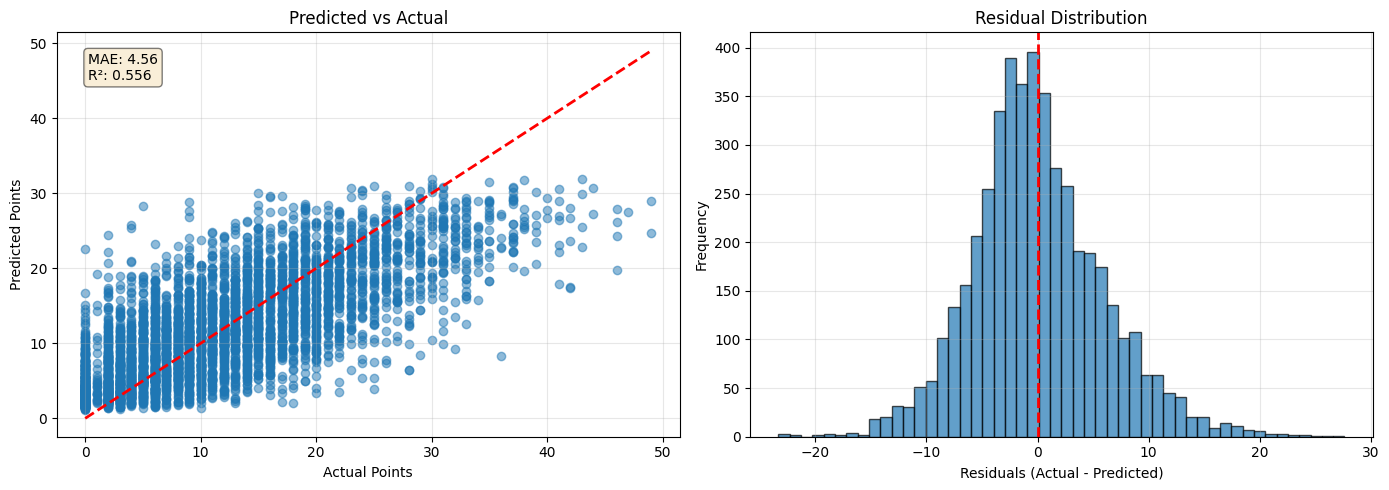

In [62]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score

# --- USE THE PREDICTIONS YOU JUST CALCULATED ---
y_pred_mean = pred_mean  # This is now your "median" prediction
y_pred_std = np.sqrt(pred_var) # Convert variance to std dev for plotting/metrics
y_true = val_df['PTS'].values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Scatter Plot
axes[0].scatter(y_true, y_pred_mean, alpha=0.5)
axes[0].plot([y_true.min(), y_true.max()], 
             [y_true.min(), y_true.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Points')
axes[0].set_ylabel('Predicted Points')
axes[0].set_title('Predicted vs Actual')
axes[0].grid(True, alpha=0.3)

# Calculate Metrics
mae = mean_absolute_error(y_true, y_pred_mean)
r2 = r2_score(y_true, y_pred_mean)
axes[0].text(0.05, 0.95, f'MAE: {mae:.2f}\nR²: {r2:.3f}', 
             transform=axes[0].transAxes,
             verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 2. Residuals Plot
residuals = y_true - y_pred_mean
axes[1].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Residuals (Actual - Predicted)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [65]:
mean_importance_raw = mean_model.feature_importances_  
var_importance_raw = var_model.feature_importances_    

# Average across the 2 distributions
mean_importance = mean_importance_raw.mean(axis=0)  
var_importance = var_importance_raw.mean(axis=0)    

# NOW create the DataFrame
feature_importance_df = pd.DataFrame({
    'feature': featuresV4,
    'mean_model': mean_importance,  
    'var_model': var_importance    
}).sort_values('mean_model', ascending=False)

# Display top features
print("\n" + "="*80)
print("TOP 20 FEATURES FOR PREDICTING POINTS (MEAN MODEL)")
print("="*80)
print(feature_importance_df[['feature', 'mean_model']].head(20).to_string(index=False))


TOP 20 FEATURES FOR PREDICTING POINTS (MEAN MODEL)
                           feature  mean_model
                   PTS_AVG_TO_DATE    0.198568
                   FGA_AVG_TO_DATE    0.145628
TEAM_OFF_RATING_L3_OVER_LEAGUE_AVG    0.020325
          FGA_EXPECTATION_LOCATION    0.020003
          PTS_EXPECTATION_LOCATION    0.016194
                          STARTING    0.014560
                   FTA_AVG_TO_DATE    0.011400
  GUARD_DEF_RATING_OVER_LEAGUE_AVG    0.010604
               USG_PCT_AVG_TO_DATE    0.010032
                  PLAYER_DAYS_REST    0.009710
              GAMES_PLAYED_TO_DATE    0.009668
            PLUS_MINUS_AVG_TO_DATE    0.009256
          USUAL_STARTERS_AVAILABLE    0.009008
                MIN_STD_10_TO_DATE    0.008903
                GAMES_WITHOUT_STAR    0.008566
                  FG3A_AVG_TO_DATE    0.008476
                PTS_STD_10_TO_DATE    0.008278
                 MIN_STD_5_TO_DATE    0.008030
             USG_PCT_STD_5_TO_DATE    0.007827
        

In [66]:
feature_importance_df = pd.DataFrame({
    'feature': featuresV4,
    'mean_model': mean_importance,  
    'var_model': var_importance    
}).sort_values('var_model', ascending=False)


print("\n" + "="*80)
print("TOP 20 FEATURES FOR PREDICTING POINTS (VAR MODEL)")
print("="*80)
print(feature_importance_df[['feature', 'var_model']].head(20).to_string(index=False))


TOP 20 FEATURES FOR PREDICTING POINTS (VAR MODEL)
                           feature  var_model
                   FGA_AVG_TO_DATE   0.081985
                   PTS_AVG_TO_DATE   0.044515
            PLUS_MINUS_AVG_TO_DATE   0.016569
          FGA_EXPECTATION_LOCATION   0.016167
                 MIN_STD_5_TO_DATE   0.014986
             USG_PCT_STD_5_TO_DATE   0.014015
       PLUS_MINUS_L5_OVER_BASELINE   0.013775
            PTS_VARIANCE_STABILITY   0.013102
                PTS_STD_10_TO_DATE   0.012535
                MIN_STD_10_TO_DATE   0.012502
         TS_PCT_VARIANCE_STABILITY   0.012502
             TS_PCT_STD_10_TO_DATE   0.012109
         FT_PCT_VARIANCE_STABILITY   0.011998
TEAM_OFF_RATING_L3_OVER_LEAGUE_AVG   0.011963
              TS_PCT_STD_5_TO_DATE   0.011839
                FGA_STD_10_TO_DATE   0.011607
            USG_PCT_STD_10_TO_DATE   0.011532
      PLUS_MINUS_L10_OVER_BASELINE   0.011406
          USG_PCT_L5_OVER_BASELINE   0.011322
                  FG3A_AVG_TO

In [67]:
import joblib

# Save NGBoost split models (mean, variance, calibration factor)
joblib.dump(mean_model, 'SAVED_MODELS/NGBOOST_PTS_MEAN_MODEL_PRODUCTIONv2.pkl')
joblib.dump(var_model, 'SAVED_MODELS/NGBOOST_PTS_VAR_MODEL_PRODUCTIONv2.pkl')
joblib.dump(cal_factor, 'SAVED_MODELS/NGBOOST_PTS_CALIBRATION_FACTOR_PRODUCTIONv2.pkl')
joblib.dump(opt_params, 'SAVED_MODELS/NGBOOST_PTS_OPT_PARAMS_PRODUCTIONv2.pkl')
joblib.dump(featuresV4, 'SAVED_MODELS/feature_listv2.pkl')

print("="*80)
print("Models saved successfully!")
print("="*80)
print("✓ Mean model")
print("✓ Variance model")
print("✓ OPT PARAMS")
print("✓ Calibration factor")
print("✓ Feature list")

Models saved successfully!
✓ Mean model
✓ Variance model
✓ OPT PARAMS
✓ Calibration factor
✓ Feature list


In [14]:
# import joblib

# # Save NGBoost split models (mean, variance, calibration factor)
# joblib.dump(mean_model, 'SAVED_MODELS/NGBOOST_PTS_MEAN_MODEL_BACKTEST.pkl')
# joblib.dump(variance_model, 'SAVED_MODELS/NGBOOST_PTS_VAR_MODEL_BACKTEST.pkl')
# joblib.dump(cal_factor, 'SAVED_MODELS/NGBOOST_PTS_CALIBRATION_FACTOR_BACKTEST.pkl')

# joblib.dump(features, 'SAVED_MODELS/feature_list.pkl')

# print("="*80)
# print("Models saved successfully!")
# print("="*80)
# print("✓ Mean model")
# print("✓ Variance model")
# print("✓ Calibration factor")
# print("✓ Feature list")